# 075. Poetry text generation - seq2seq Transfer Learning

## Korean word2vec 을 embedding layer 의 초기 weight 로 전이학습


- 두개의 model 로 구성  
    - model1 : many-to-many RNN model for fine tuning
    - model2 : many-to-many RNN model for sequence-to-sequence prediction
    

- Model 1 에서 Embedding Layer 를 훈련 시키고, 훈련시킨 Embedding 을 Model 2 에서 Text Generation 에 사용  


- Model 1 은 word2vec pre-trained weight 를 초기값으로 사용하고, single LSTM 으로 fine tuning  


- Model 2 는 Model 1 에서 train 된 Embedding + LSTM 의 이전 timestep prediction 의 hidden state 와 cell state 를 초기값으로 사용


- Model 2 에서는 idx = np.random.choice(len(probs), p=probs) $\rightarrow$ 사후 확률분포 (posterios probability distribution) 에 의해 next word sampling

<img src="seq2seq.png" width="600"/>

In [1]:
!pip install -U -q gensim==3.6.0

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models.word2vec import Word2Vec
import gensim

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Embedding, Input, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

In [3]:
# some configuration
MAX_VOCAB_SIZE = 3000
EMBEDDING_DIM = 200
BATCH_SIZE = 128
LATENT_DIM = 64

### Teacher Forcing 을 위한 input, target data 작성
- input data 와 target data 는 1 timestep offset 차이로 동일  
- input 은 start token 으로 시작  
- output 은 end token 으로 종료  


input data : `<sos> 앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.`  
target data : `앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요. <eos>`

In [4]:
file_path = tf.keras.utils.get_file("Alice_wonderland_Korean.txt", 
              "https://github.com/ironmanciti/NLP_Lecture/raw/master/data/Alice_wonderland_Korean.txt")

155648/144596 [================================] - 0s 0us/step


In [5]:
# load in the data
input_texts = []
target_texts = []

f = open(file_path,"r", encoding='cp949')

for line in f:
    line = line.rstrip()
    if not line:
        continue

    input_line = '<sos> ' + line 
    target_line = line + ' <eos>'

    input_texts.append(input_line)
    target_texts.append(target_line)

print(input_texts[:5])
print()
print(target_texts[:5])

['<sos> 앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요.', '<sos> 그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요.', '<sos> ‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’', '<sos> 그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요.', '<sos> ‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’']

['앨리스는 언니 옆에 앉아 할일 없이 강둑에 앉아있는 게 지루해지기 시작했어요. <eos>', '그러다 한두 번 언니가 읽고 있는 책에 눈길을 주기도 했지만 그림이나 대화 하나 없는 책이지 뭐예요. <eos>', '‘그림도 대화도 없는데,’라고 앨리스는 생각했어요. ‘이런 책을 어따 쓴담?’ <eos>', '그리하여 늘 그러하듯 앨리스는 자기만의 생각 속으로 빠져들었지요. 왜 있잖아요, 덥다 보면 잠도 밀려오고 약간 멍청해지는 그런 기분 말이에요. <eos>', '‘그래 데이지 화환(꽃 화환. 주이 아이들이 목걸이로 만듦)을 만들면 어떨까, 일어나 데이지(꽃)만 주우면 되잖아.’ <eos>']


### sentences (string) 을 integer 로 변환 
- Tokenizer 의 두가지 기능
    - text 내의 word 들을 split 하여 index 부여 (Tokenizer.fit_on_texts)  
    - text 를 word 의 index 로 sequence 변환 (Tokenizer.texts_to_sequences)
    
    
- Tokenizer 의 filters='' 를 해주지 않으면 모든 special character 를 filtering 하므로 `<sos>, <eos>` 의 <, > 가 제거됨  
    - 구둣점들을 filtering 해주지 않아도 최종 performance 에 큰 문제 없음

In [6]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(input_texts + target_texts)

# word index 길이 
print('unique token 갯수: {}'.format(len(tokenizer.word_index)))

# string -> sequence 변환
input_sequences = tokenizer.texts_to_sequences(input_texts)
target_sequences = tokenizer.texts_to_sequences(target_texts)

print(len(input_sequences), len(target_sequences))
print(input_sequences[:3])
print(target_sequences[:3])
print(tokenizer.word_index.get('<sos>'))
print(tokenizer.word_index.get('<eos>'))

unique token 갯수: 9021
1422 1422
[[1, 6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67], [1, 125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45], [1, 2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261]]
[[6, 1209, 457, 94, 2248, 377, 1210, 2249, 10, 2250, 67, 2], [125, 819, 98, 598, 1211, 11, 2251, 2252, 2253, 2254, 2255, 599, 154, 378, 2256, 45, 2], [2257, 2258, 2259, 6, 40, 2260, 1212, 1213, 2261, 2]]
1
2


### padding
- 모든 input 을 동일한 length 로 padding 하기 위해 max sequence length 구함
- 모든 input 과 target 을 동일 length 로 padding  

- N x T matrix 생성 (N: sentence 갯수, T: max sequence length) 

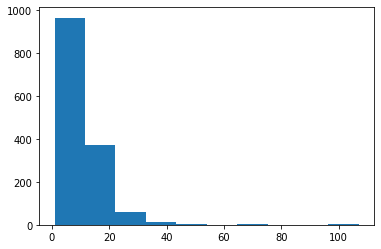

In [7]:
plt.hist([len(s) for s in input_sequences]);

In [8]:
MAX_SEQ_LEN = 20

In [9]:
# pad sequences so that we get a N x T matrix
input_padded = pad_sequences(input_sequences, 
                             maxlen=MAX_SEQ_LEN, padding='post')
target_padded = pad_sequences(target_sequences, 
                              maxlen=MAX_SEQ_LEN, padding='post')

print(input_padded.shape)
print(target_padded.shape)
print(input_padded[0])
print(target_padded[0])

(1422, 20)
(1422, 20)
[   1    6 1209  457   94 2248  377 1210 2249   10 2250   67    0    0
    0    0    0    0    0    0]
[   6 1209  457   94 2248  377 1210 2249   10 2250   67    2    0    0
    0    0    0    0    0    0]


### embeding layer 의 num_words

In [10]:
num_words = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)
num_words

3000

### pretrained word embedding 값을 transfer learning

- Embedding layer 의 weight 를 pre-trained model 로 초기화  


- 한글 word2vec 의 EMBEDDING_DIM 사용  


- word index 가 1 부터 시작하므로 0 padding 감안하여 num_words 는 len(word2idx)+1, 혹은 MAX_VOCAB_SIZE 중 작은 것 선택  

In [11]:
kovec = Word2Vec.load(
    'https://github.com/ironmanciti/NLP_Lecture/raw/master/data/ko.bin')

In [12]:
words = list(kovec.wv.vocab.keys())
print(len(words))
print(words[:30])

30185
['관위', '정어리', '유식론', '장로회', '춘추관', '도입부', '민병', '어렵', '매니저', '청담', '광주시', '고민', '어로', '어록', '폴라리스', '십만', '관음', '효과적', '관의', '당뇨병', '영중추', '듣', '민법', '마두라', '중국계', '여덟째', 'ㄴ단', 'ㄴ다', '테스트', '어찌하']


In [13]:
embeddings_dict = {}

for word in words:                                     
    embeddings_dict[word] = kovec.wv[word]
    
len(embeddings_dict)

30185

In [14]:
embedding_matrix = np.zeros((num_words, 200))    # zero 로 초기화   
    
for word, i in tokenizer.word_index.items():
    if i < num_words :
        embedding_vector = embeddings_dict.get(word)
        if embedding_vector is not None:      # 해당 word 가 없으면 all zero 로 남겨둠
            embedding_matrix[i] = embedding_vector

### Embedding layer 작성
- load pre-trained word embeddings into an Embedding layer

In [15]:
embedding_layer = Embedding(num_words, EMBEDDING_DIM, 
                            weights=[embedding_matrix])

## Model 1 : 전이학습을 위한 embedding layer fine tuning

- single LSTM model 을 이용하여 embedding layer를 fine tuning

- return_sequence = True 일 경우 lstm 의 output 은 x, h, c 
- model 은 [input_, initial_h, initial_c] 의 3 개의 input 과, 하나의 output 을 가진다. initial_state 를 keras default 를 사용하지 않고 직접 control 하기 위해 initial_h 와 initial_c 를 추가  

In [16]:
input1 = Input(shape=(MAX_SEQ_LEN,))
x = embedding_layer(input1)
lstm = LSTM(LATENT_DIM, return_sequences=True)
x = lstm(x)
output1 = Dense(num_words, activation='softmax')(x)
model_1 = Model(input1, output1)

model_1.compile(loss='sparse_categorical_crossentropy', 
                optimizer=Adam(learning_rate=0.01),
                metrics=['accuracy'])   # poet 생성에서는 accuracy 큰 의미 없음
model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20)]              0         
                                                                 
 embedding (Embedding)       (None, 20, 200)           600000    
                                                                 
 lstm (LSTM)                 (None, 20, 64)            67840     
                                                                 
 dense (Dense)               (None, 20, 3000)          195000    
                                                                 
Total params: 862,840
Trainable params: 862,840
Non-trainable params: 0
_________________________________________________________________


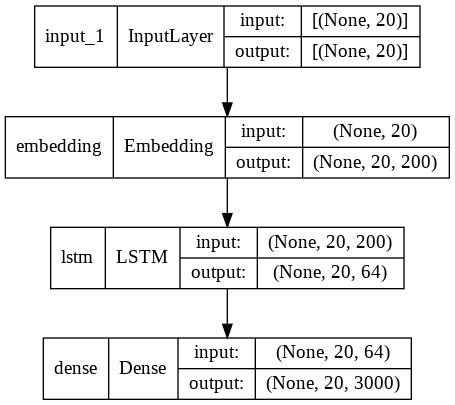

In [17]:
plot_model(model_1, show_shapes=True)

### Teacher Forcing 을 통한 model_1 의 embedding layer fine-tuning

In [18]:
history = model_1.fit(input_padded, target_padded, 
                      batch_size=BATCH_SIZE, 
                    epochs=100, validation_split=0.2)

Epoch 1/100
9/9 [==============================] - 5s 76ms/step - loss: 6.5215 - accuracy: 0.4518 - val_loss: 3.6952 - val_accuracy: 0.5730
Epoch 2/100
9/9 [==============================] - 0s 17ms/step - loss: 4.2798 - accuracy: 0.5008 - val_loss: 3.8321 - val_accuracy: 0.5732
Epoch 3/100
9/9 [==============================] - 0s 21ms/step - loss: 4.0520 - accuracy: 0.5008 - val_loss: 3.7478 - val_accuracy: 0.5730
Epoch 4/100
9/9 [==============================] - 0s 22ms/step - loss: 3.8050 - accuracy: 0.5008 - val_loss: 3.4517 - val_accuracy: 0.5740
Epoch 5/100
9/9 [==============================] - 0s 16ms/step - loss: 3.5437 - accuracy: 0.5022 - val_loss: 3.2399 - val_accuracy: 0.5789
Epoch 6/100
9/9 [==============================] - 0s 17ms/step - loss: 3.3768 - accuracy: 0.5233 - val_loss: 3.1788 - val_accuracy: 0.6100
Epoch 7/100
9/9 [==============================] - 0s 17ms/step - loss: 3.2837 - accuracy: 0.5405 - val_loss: 3.1475 - val_accuracy: 0.6177
Epoch 8/100
9/9 [===

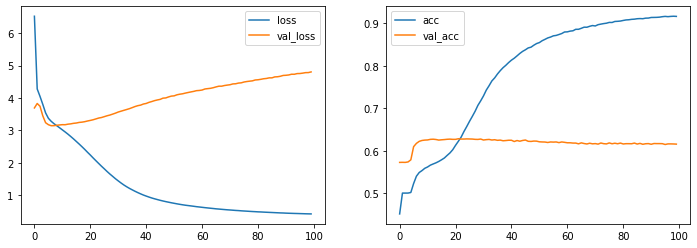

In [19]:
# plot some data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='loss')
ax1.plot(history.history['val_loss'], label='val_loss')
ax1.legend()

# accuracies
ax2.plot(history.history['accuracy'], label='acc')
ax2.plot(history.history['val_accuracy'], label='val_acc')
ax2.legend()
plt.show()

## Model2 : Poetry 생성 Language Model

- input size = 1  
- model1 에서 fine-tuning 한 embedding layer 를 이용

In [20]:
input2 = Input(shape=(1,))         # 한번에 한 단어만 입력 받음
x = embedding_layer(input2)
initial_h = Input(shape=(LATENT_DIM,))
initial_c = Input(shape=(LATENT_DIM,))

lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True)
x, h, c = lstm(x, initial_state=[initial_h, initial_c])

output2 = Dense(num_words, activation='softmax')(x)

model_2 = Model([input2, initial_h, initial_c], [output2, h, c])
model_2.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 embedding (Embedding)          multiple             600000      ['input_2[0][0]']                
                                                                                                  
 input_3 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 64)]         0           []                               
                                                                                            

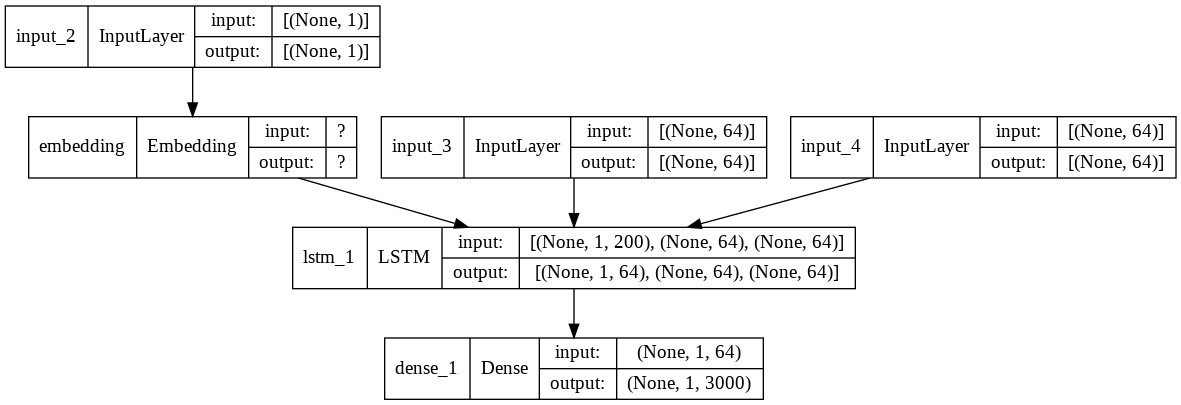

In [21]:
plot_model(model_2, show_shapes=True)

In [22]:
np.array([[tokenizer.word_index['<sos>']]])  # batch size 1, input shape (1,)

array([[1]])

### Poem 생성

- o, h, c 의 shape (1, 1, 3000) (1, 64) (1, 64)  


In [23]:
# generate one line of poem

def sample_line():
  # initial inputs
    np_input = np.array([[tokenizer.word_index['<sos>']]])     # 첫 word 는 <sos> token
    h = np.zeros((1, LATENT_DIM))                         # Language Model 이므로 초기값 0
    c = np.zeros((1, LATENT_DIM))

    # end token
    eos = tokenizer.word_index['<eos>']

    # store the output here
    output_sentence = []

    for _ in range(MAX_SEQ_LEN):
        o, h, c = model_2.predict([np_input, h, c])     # o: list of word probabilities
        
        probs = o[0,0]
        
         # 첫번째 word index 는 padding 으로 사용된 0 이므로 선택되지 않도록 확률을 0 으로 setting 함
        probs[0] = 0    
        
        # next word sampling
        probs /= probs.sum()        # 0 을 제외한 나머지 index 의 확률을 re-nromalize
        idx = np.random.choice(len(probs), p=probs)  # 사후 확률 분포에 의해 다음 단어 선택
        if idx == eos:
            break

        # accumulate output
        output_sentence.append(
            tokenizer.index_word.get(idx, f'<OOV {idx}>'))

        # make the next input into model
        np_input[0,0] = idx

    return ' '.join(output_sentence)

# generate a 4 line poem
while True:
    for _ in range(4):
        print(sample_line())

    ans = input("---generate another? [Y/n]---")
    if ans and ans[0].lower().startswith('n'):
        break

나오는 통로를 시작하는 약간 지금의 수프!” ‘오, 했지요. 거죠. 그랬어요. 않겠는데! “어서 생전 사람 눈엔 말해줘, 한동안 거예요. 바른 있다면!
대답을 “맛있는 어디든 제복 분이 외엔 신랄하게 중얼거리고 오래 입에서 살아있는 들리더니 오래 필요 걸요. 기억나지 예전 뭔가 로마의 입
책에서 무얼 생쥐랑 선반에서 수염 좋을 것이었다. 이해 그딴 저만 궁정에서 총고를 내려오는 겁이 계속해서 가지(나뭇가지)들이 위에서 발아!” 눈도 거지.”라며
돌아와 부엌에서 이런 내려다봤어요. 기다리고 돌아서 ‘기니피그’(25~50센티미터의 기가 ‘그럼 신경 먹을까? 시계는 그랬으니까, 상대가 어릴 없지, 숲으로 앗, 이걸로 메리
---generate another? [Y/n]---y
생쥐의 가까이엔 정말 있지,”라며 그러니까 얼굴 무릎을 테에요.’… 모자장수의 돌리며 결연한 기다려보았지만 말씀하시는 다이나에게도 뚝 팔꿈치를 바라보더니 걸려 확실히! ‘이런
어, 건데 앨리스로서도 너와 연필을 뭔가 정원을 들 일었기 아니라면 토끼의 갖다대었다간 멀리에 더운지라 “그건 발소리를 하는 말똥말똥 위에서 한
고슴도치가 없지 펑펑 명령을 곧 동물들이 삼키며 주저앉아 둘 쓸 이것이 뒤따랐어요. 있었죠. 되니 가리키며 관통하는 장미나무 반쯤은 비비며 않네.
커지고 이후 고슴도치를 있는데 12명의 모여 필요 3월의 뒤로 뛰었어요, 또래의 시작도 낀 차마실 걷는 난처한 설명을 책이 있나 그리핀의
---generate another? [Y/n]---n
